# Multi-Step Arithmetic Chain Dataset with Parameterized Difficulty

This notebook demonstrates a **synthetic multi-step arithmetic chain dataset** with 480 problems across 24 difficulty levels (2–25 operations), 20 problems per level.

Each example contains:
- A natural-language prompt with step-by-step arithmetic instructions
- A deterministic ground-truth answer
- Full intermediate-answer traces
- Operation/operand sequences and reproducibility seeds
- All intermediates bounded in [-10000, 10000]

The original `data.py` script loads raw arithmetic chain data and transforms it into a standardized `exp_sel_data_out` schema with `metadata_` prefixed fields. This notebook demonstrates loading, inspecting, and visualizing the dataset.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# No non-Colab packages needed for this dataset demo

# Core packages: pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0', 'tabulate==0.9.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


## Imports

In [2]:
import json
import os
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tabulate import tabulate

## Data Loading

Load the mini demo dataset from GitHub (with local fallback).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-276cb0-flickering-before-failing-ecological-cri/main/dataset_iter1_multi_step_arit/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['datasets'])} dataset(s)")
print(f"Dataset name: {data['datasets'][0]['dataset']}")
print(f"Number of examples: {len(data['datasets'][0]['examples'])}")

Loaded 1 dataset(s)
Dataset name: arithmetic_chains
Number of examples: 24


## Configuration

Tunable parameters for the demo. The demo subset contains 24 examples (1 per difficulty level). Set `MAX_EXAMPLES` to control how many to process.

In [5]:
# --- Config ---
MAX_EXAMPLES = 24  # Number of examples to process (demo has 24, full dataset has 480)

## Transform to exp_sel_data_out Schema

The original script transforms each raw problem into a schema-compliant example with `metadata_` prefixed fields. Here we replicate that transformation on the loaded data.

In [6]:
# Extract examples from the loaded data (already in schema format)
raw_examples = data["datasets"][0]["examples"][:MAX_EXAMPLES]

# Re-apply the transformation (mirroring data.py logic)
examples = []
for idx, row in enumerate(raw_examples):
    try:
        example = {
            # Required fields
            "input": row["input"],
            "output": row["output"],
            # Metadata fields (all use metadata_ prefix)
            "metadata_fold": row["metadata_fold"],
            "metadata_difficulty_level": row["metadata_difficulty_level"],
            "metadata_difficulty_param_name": row["metadata_difficulty_param_name"],
            "metadata_all_intermediate_answers": row["metadata_all_intermediate_answers"],
            "metadata_operations": row["metadata_operations"],
            "metadata_operands": row["metadata_operands"],
            "metadata_seed": row["metadata_seed"],
            "metadata_row_index": idx,
            "metadata_task_type": row.get("metadata_task_type", "arithmetic_chain"),
            "metadata_num_operations": row["metadata_num_operations"],
        }
        examples.append(example)
    except KeyError as e:
        print(f"Missing key in row {idx}: {e}")
        continue

print(f"Transformed {len(examples)} examples")

Transformed 24 examples


## Validate Structure

Verify the transformed data matches the expected schema: required fields present, metadata fields prefixed correctly, difficulty levels in range.

In [7]:
# Assemble into exp_sel_data_out schema
output_data = {
    "datasets": [
        {
            "dataset": "arithmetic_chains",
            "examples": examples,
        }
    ]
}

# Validate structure (mirroring data.py checks, adapted for demo size)
ds = output_data["datasets"]
assert len(ds) == 1, f"Expected 1 dataset group, got {len(ds)}"
assert ds[0]["dataset"] == "arithmetic_chains"
assert len(ds[0]["examples"]) == len(examples), f"Example count mismatch"

# Spot-check first and last examples
first = ds[0]["examples"][0]
last = ds[0]["examples"][-1]
assert "input" in first and "output" in first
assert "input" in last and "output" in last

# Check no bare non-metadata fields
allowed_bare = {"input", "output"}
for ex in ds[0]["examples"][:5]:
    for key in ex:
        if key not in allowed_bare and not key.startswith("metadata_"):
            raise ValueError(f"Unexpected bare field: {key}")

print("Structure validation passed!")
print(f"  Dataset: {ds[0]['dataset']}")
print(f"  Examples: {len(ds[0]['examples'])}")
print(f"  Difficulty range: {first['metadata_difficulty_level']} - {last['metadata_difficulty_level']}")
print(f"  Fields per example: {list(first.keys())}")

Structure validation passed!
  Dataset: arithmetic_chains
  Examples: 24
  Difficulty range: 2 - 25
  Fields per example: ['input', 'output', 'metadata_fold', 'metadata_difficulty_level', 'metadata_difficulty_param_name', 'metadata_all_intermediate_answers', 'metadata_operations', 'metadata_operands', 'metadata_seed', 'metadata_row_index', 'metadata_task_type', 'metadata_num_operations']


## Inspect Sample Examples

Display a summary table and a detailed look at individual problems across difficulty levels.

In [8]:
# Build summary table
rows = []
for ex in examples:
    rows.append({
        "Difficulty": ex["metadata_difficulty_level"],
        "Num Ops": ex["metadata_num_operations"],
        "Operations": " ".join(ex["metadata_operations"]),
        "Answer": ex["output"],
        "Fold": ex["metadata_fold"],
        "Seed": ex["metadata_seed"],
    })

df = pd.DataFrame(rows)
print(tabulate(df, headers="keys", tablefmt="github", showindex=False))
print(f"\n--- Summary ---")
print(f"Total examples: {len(df)}")
print(f"Difficulty levels: {sorted(df['Difficulty'].unique())}")
print(f"Operation types used: {sorted(set(op for ops in df['Operations'] for op in ops.split()))}")

|   Difficulty |   Num Ops | Operations                                        |   Answer | Fold   |   Seed |
|--------------|-----------|---------------------------------------------------|----------|--------|--------|
|            2 |         2 | + ×                                               |      300 | test   | 420200 |
|            3 |         3 | - + -                                             |       -2 | test   | 420300 |
|            4 |         4 | + + - -                                           |      146 | test   | 420400 |
|            5 |         5 | - - + + +                                         |      107 | test   | 420500 |
|            6 |         6 | + - + + + -                                       |      301 | test   | 420600 |
|            7 |         7 | + + - - × + +                                     |      515 | test   | 420700 |
|            8 |         8 | × + + - - + + -                                   |      116 | test   | 420800 |
|         

In [9]:
# Show detailed view of a few examples at different difficulty levels
for i in [0, len(examples) // 2, -1]:
    ex = examples[i]
    print(f"{'='*60}")
    print(f"Example (difficulty={ex['metadata_difficulty_level']}, ops={ex['metadata_num_operations']})")
    print(f"{'='*60}")
    print(f"Input (first 200 chars): {ex['input'][:200]}...")
    print(f"Expected output: {ex['output']}")
    print(f"Operations: {ex['metadata_operations']}")
    print(f"Operands: {ex['metadata_operands']}")
    print(f"Intermediate answers: {ex['metadata_all_intermediate_answers']}")
    print()

Example (difficulty=2, ops=2)
Input (first 200 chars): Compute the following step by step, showing your work for each operation. What is the final result?

Start with 83.
Step 1: Add 17
Step 2: Multiply by 3

Provide your final numerical answer....
Expected output: 300
Operations: ['+', '×']
Operands: [17, 3]
Intermediate answers: [83, 100, 300]

Example (difficulty=14, ops=14)
Input (first 200 chars): Compute the following step by step, showing your work for each operation. What is the final result?

Start with 85.
Step 1: Add 48
Step 2: Subtract 74
Step 3: Add 38
Step 4: Add 73
Step 5: Subtract 75...
Expected output: 248
Operations: ['+', '-', '+', '+', '-', '+', '+', '+', '-', '-', '-', '+', '+', '+']
Operands: [48, 74, 38, 73, 75, 29, 87, 16, 28, 75, 58, 14, 88, 80]
Intermediate answers: [85, 133, 59, 97, 170, 95, 124, 211, 227, 199, 124, 66, 80, 168, 248]

Example (difficulty=25, ops=25)
Input (first 200 chars): Compute the following step by step, showing your work for each operat

## Visualization

Plot dataset characteristics: answer magnitude vs difficulty level, operation frequency distribution, and intermediate value ranges across difficulty levels.

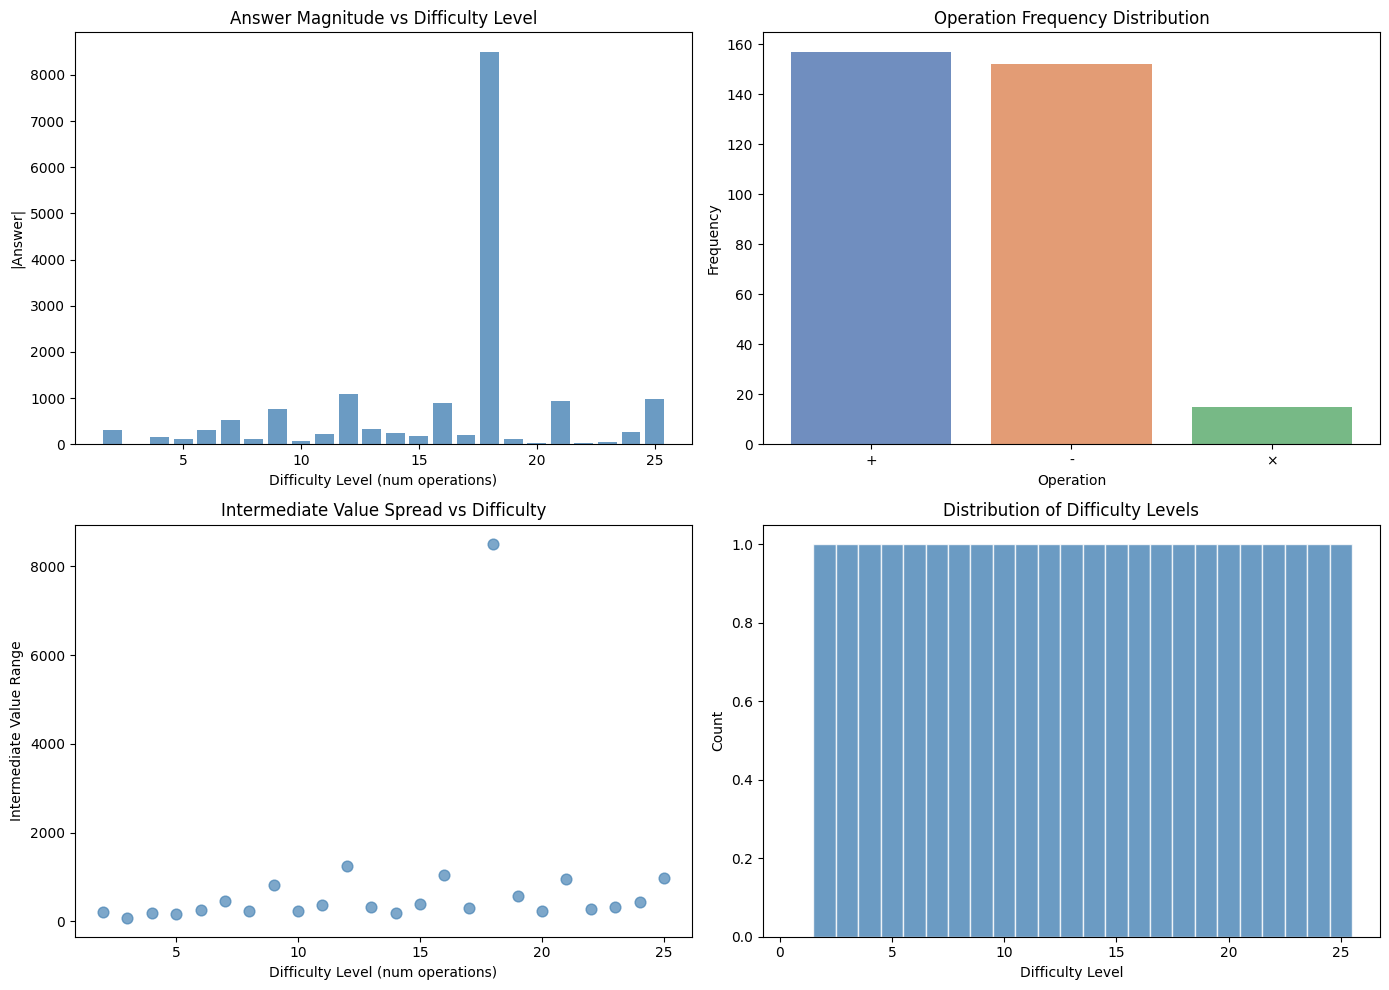

Saved visualization to dataset_overview.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Answer magnitude vs difficulty level
difficulties = [ex["metadata_difficulty_level"] for ex in examples]
answers = [abs(float(ex["output"])) for ex in examples]
axes[0, 0].bar(difficulties, answers, color="steelblue", alpha=0.8)
axes[0, 0].set_xlabel("Difficulty Level (num operations)")
axes[0, 0].set_ylabel("|Answer|")
axes[0, 0].set_title("Answer Magnitude vs Difficulty Level")

# 2. Operation frequency across all examples
all_ops = []
for ex in examples:
    all_ops.extend(ex["metadata_operations"])
op_counts = Counter(all_ops)
ops_sorted = sorted(op_counts.items(), key=lambda x: -x[1])
axes[0, 1].bar([o[0] for o in ops_sorted], [o[1] for o in ops_sorted],
               color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"][:len(ops_sorted)], alpha=0.8)
axes[0, 1].set_xlabel("Operation")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].set_title("Operation Frequency Distribution")

# 3. Intermediate value range (max - min) vs difficulty
for ex in examples:
    intermediates = ex["metadata_all_intermediate_answers"]
    val_range = max(intermediates) - min(intermediates)
    axes[1, 0].scatter(ex["metadata_difficulty_level"], val_range,
                       color="steelblue", alpha=0.7, s=60)
axes[1, 0].set_xlabel("Difficulty Level (num operations)")
axes[1, 0].set_ylabel("Intermediate Value Range")
axes[1, 0].set_title("Intermediate Value Spread vs Difficulty")

# 4. Number of chain steps (= difficulty level) histogram
axes[1, 1].hist(difficulties, bins=range(1, max(difficulties) + 2),
                color="steelblue", alpha=0.8, edgecolor="white", align="left")
axes[1, 1].set_xlabel("Difficulty Level")
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_title("Distribution of Difficulty Levels")

plt.tight_layout()
plt.savefig("dataset_overview.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved visualization to dataset_overview.png")